<a href="https://colab.research.google.com/github/mohamedjunaidm2025cse-create/FDS-Lab-Exp/blob/main/exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Roll_No Student Department  Marks  Performance  Year
0      101    Arun        CSE     85           88     1
1      102   Kavin         IT     92           90     2
2      103   Rahul        ECE     78           75     1
3      104   Priya        CSE     89           92     3
4      105   Divya         IT     81           84     2

Missing values:
Roll_No        0
Student        0
Department     0
Marks          0
Performance    0
Year           0
dtype: int64

Summary Statistics:
         Roll_No      Marks  Performance      Year
count    8.00000   8.000000     8.000000  8.000000
mean   104.50000  85.375000    86.000000  2.500000
std      2.44949   6.696214     6.480741  1.195229
min    101.00000  76.000000    75.000000  1.000000
25%    102.75000  80.250000    82.750000  1.750000
50%    104.50000  86.000000    87.000000  2.500000
75%    106.25000  89.750000    90.500000  3.250000
max    108.00000  95.000000    94.000000  4.000000

Department Summary:
  Department  Mar

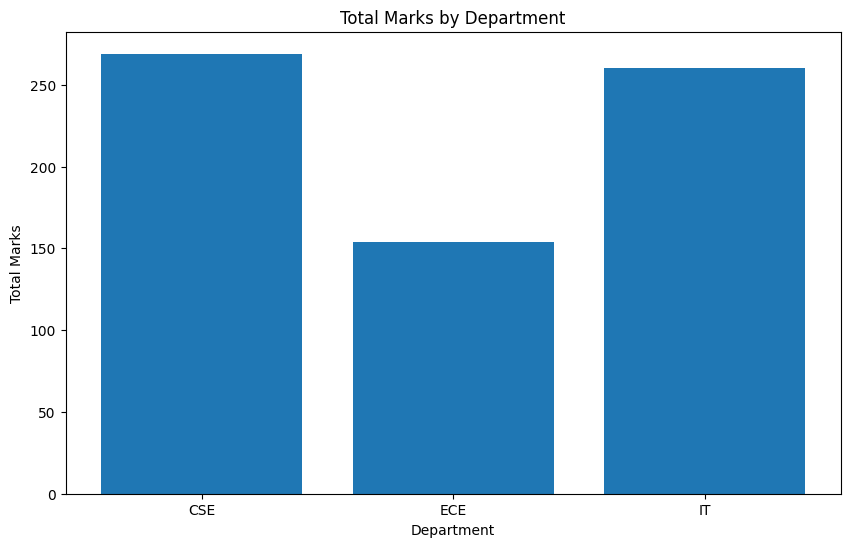

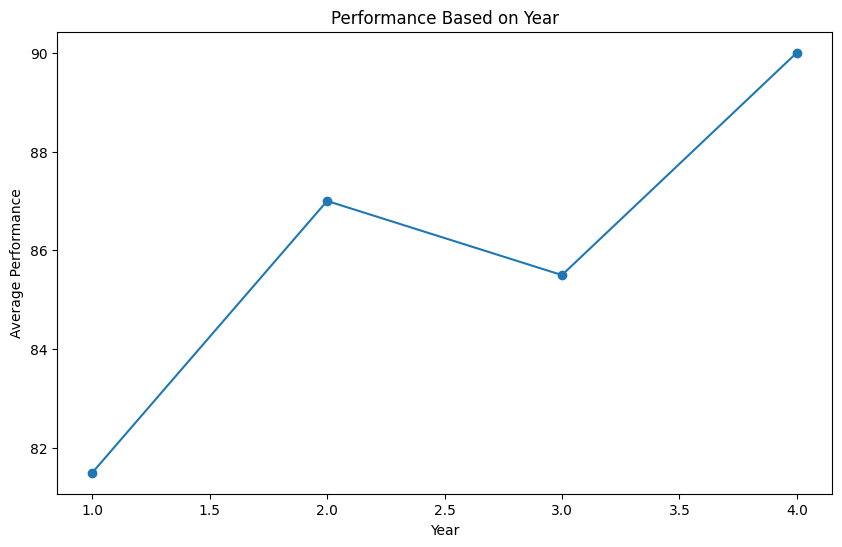


Pivot Table:
Year           1     2     3     4
Department                        
CSE         88.0   0.0  92.0  94.0
ECE         75.0   0.0  79.0   0.0
IT           0.0  87.0   0.0  86.0

Correlation Matrix:
              Roll_No     Marks  Performance      Year
Roll_No      1.000000  0.065322     0.044996  0.878310
Marks        0.065322  1.000000     0.921735  0.437308
Performance  0.044996  0.921735     1.000000  0.442627
Year         0.878310  0.437308     0.442627  1.000000


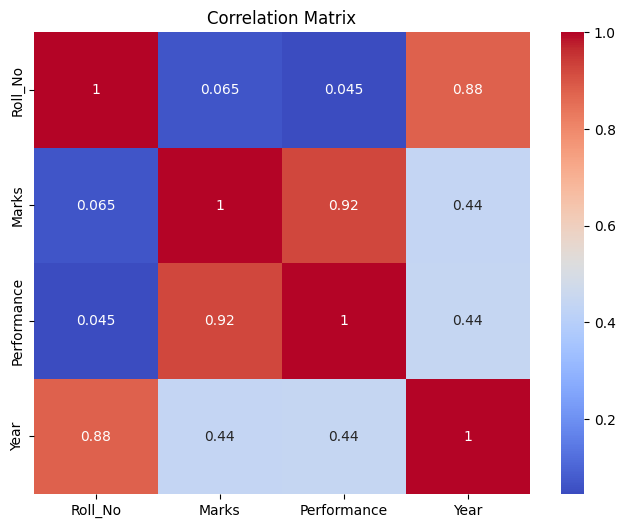

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create student data directly
data = {
    'Roll_No': [101, 102, 103, 104, 105, 106, 107, 108],
    'Student': ['Arun', 'Kavin', 'Rahul', 'Priya', 'Divya', 'Vijay', 'Sneha', 'Ajay'],
    'Department': ['CSE', 'IT', 'ECE', 'CSE', 'IT', 'ECE', 'CSE', 'IT'],
    'Marks': [85, 92, 78, 89, 81, 76, 95, 87],
    'Performance': [88, 90, 75, 92, 84, 79, 94, 86],
    'Year': [1, 2, 1, 3, 2, 3, 4, 4]
}

df = pd.DataFrame(data)

print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# Fill missing marks
df['Marks'] = df['Marks'].fillna(df['Marks'].mean())

# Remove rows with missing important data
df.dropna(
    subset=['Student', 'Department', 'Performance'],
    inplace=True
)

print("\nSummary Statistics:")
print(df.describe())

# Department summary
department_summary = df.groupby('Department').agg({
    'Marks': 'sum',
    'Performance': 'mean'
}).reset_index()

print("\nDepartment Summary:")
print(department_summary)

# Bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    department_summary['Department'],
    department_summary['Marks']
)

plt.xlabel('Department')
plt.ylabel('Total Marks')
plt.title('Total Marks by Department')
plt.show()

# Performance over year
performance_over_time = df.groupby(
    'Year'
)['Performance'].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(
    performance_over_time['Year'],
    performance_over_time['Performance'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Average Performance')
plt.title('Performance Based on Year')
plt.show()

# Pivot table
pivot_table = df.pivot_table(
    values='Performance',
    index='Department',
    columns='Year',
    aggfunc='mean',
    fill_value=0
)

print("\nPivot Table:")
print(pivot_table)

# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()